In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error , r2_score
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.linear_model import ElasticNet

In [2]:
df = pd.read_csv(r'D:\NVIDIA AI Course\Udemy_NVIDIA-Certified_Associate_Generative_AI_LLMs_NCA-GENL_2025-1_Downloadly.ir\Advertising.csv')
df.head()

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [3]:
# drop unnamed column as it is useless
#inlace=True means we will drop this column permanently in the original df
df.drop(columns='Unnamed: 0',inplace=True)
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


Mathematical representation of linear regression is (y = a + bx) where a is called y-interceptor and b is called slope and x is the feature.
in case we have multiple features, then the equation would be like this (Y= θ0+ θ1X1+θ2X2,….) where x1,x2 are called features,θ0 is the intercept and (θ1,θ2,θn) are coefficient

In [4]:
# let's assign the features and target
features_columns = ['TV','radio','newspaper']
X = df[features_columns]
y = df['sales']

In [5]:
#first let's split the data into 70% train and 30% test
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=4,test_size=0.3)
print(X_train.shape)
print(X_test.shape)

(140, 3)
(60, 3)


In [6]:
# feed the model to get a trained model
lr = LinearRegression()
lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [7]:
# get coefficients and interceptor
print(lr.coef_)
print(lr.intercept_)

[0.04533392 0.17715767 0.00553852]
3.09064436412511


In [8]:
#generate the predicted data
y_pred = lr.predict(X_test)
print(y_pred[:5])

[17.09777441 16.86148273 21.7761552  24.53812602 12.32008724]


Evaluation of the model to detect how the model perform
there are many evaluation functions like:
- mean absolute error
- mean squared error
- Root mean squared error
- R2 score

In [9]:
print(f"MAE is: {mean_absolute_error(y_test,y_pred)}")
print(f"MSE is: {mean_squared_error(y_test,y_pred)}")
# print(f"RMSE is: {mean_squared_error(y_test,y_pred, squared = False)}")
print(f"RMSE is: {root_mean_squared_error(y_test,y_pred)}")

MAE is: 1.2111525124980485
MSE is: 2.2237746679115578
RMSE is: 1.4912326002041256


In [10]:
# R2 score means how much variance can be explained by the given features
print(f"R2 Score is: {r2_score(y_test,y_pred)}")

R2 Score is: 0.9127220729596172


In [25]:
# Lasso Regression (L1 Regularization)
las = Lasso()
las.fit(X_train,y_train)

,alpha,1.0
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [26]:
y_pred = las.predict(X_test)
print(f"R2_Score is: {r2_score(y_test,y_pred)}")

R2_Score is: 0.9112250903194142


In [29]:
# Ridge Regression (L2 Regularization)
rid = Ridge()
rid.fit(X_train,y_train)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [30]:
y_pred = rid.predict(X_test)
print(f"R2 Score Is: {r2_score(y_test,y_pred)}")

R2 Score Is: 0.9127183051915455


In [32]:
# Elastic Net
elastic_net = ElasticNet()
elastic_net.fit(X_train,y_train)

,alpha,1.0
,l1_ratio,0.5
,fit_intercept,True
,precompute,False
,max_iter,1000
,copy_X,True
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [35]:
y_pred = elastic_net.predict(X_test)
print(f"R2 score is: {r2_score(y_test,y_pred)}")

R2 score is: 0.9117469302155123


- Assumptions of Linear Regression
- Linear relationship between features and targets

In [37]:
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


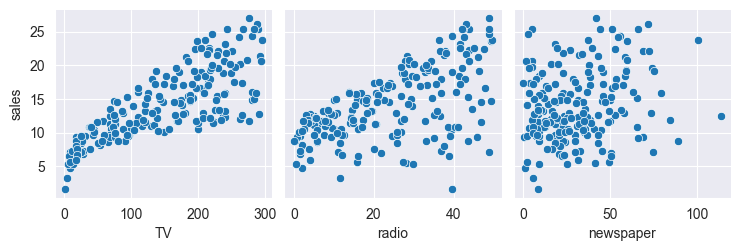

In [39]:
# to show the relation between features and target we need to plot the DF using Scatter plot
sns.pairplot(df,x_vars=['TV','radio','newspaper'],y_vars=['sales'])
plt.show()

In [41]:
# As we can see TV close to linear relation with Sales where radio & newspaper are loosely linear relationship
# we can see how much each feature is close to linear relation using the correlation
df.corr()

,TV,radio,newspaper,sales
TV,1.000000,0.054809,0.056648,0.782224
radio,0.054809,1.000000,0.354104,0.576223
newspaper,0.056648,0.354104,1.000000,0.228299
sales,0.782224,0.576223,0.228299,1.000000


as we can see correlation of TV & Sales are bigger than radio and newspaper

In [43]:
# Mean Residual = 0
residual = (y_test - y_pred)
np.mean(residual)

np.float64(-0.07559702903921825)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_5672\78598921.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(residual)


<Axes: xlabel='sales', ylabel='Density'>

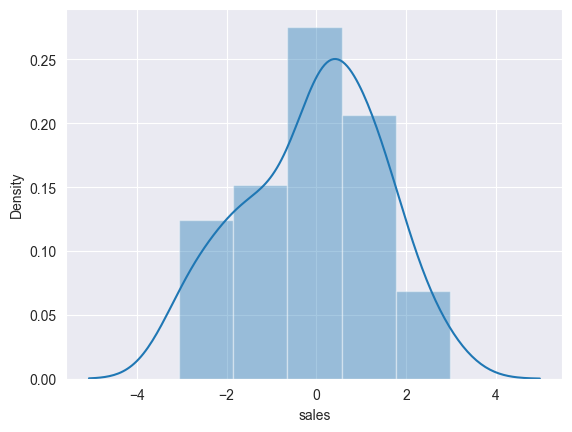

In [44]:
# Another assumption is normal distribution of error terms
sns.distplot(residual)

<Axes: xlabel='sales', ylabel='Density'>

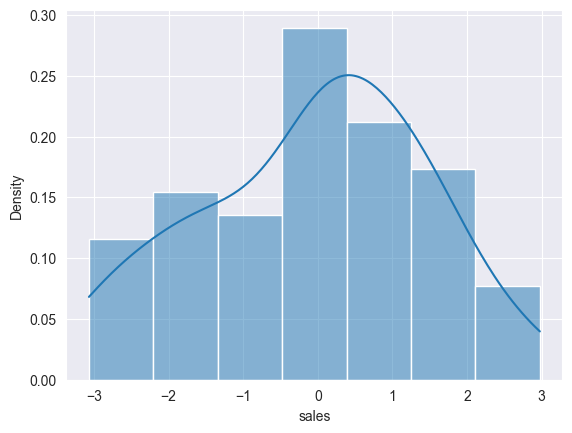

In [47]:
sns.histplot(residual,kde=True, stat="density")

In [48]:
# Multi collinearity
# VIF score

In [60]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [64]:
def vif_scor(X):
    X_arr = X.values
    vif = [variance_inflation_factor(X_arr,i) for i in range(X.shape[1])]
    vif_score = pd.DataFrame()
    vif_score['vif_score'] = vif
    vif_score['Features'] = X.columns
    return vif_score

In [65]:
vif_scor(X_train)

,vif_score,Features
0,2.583582,TV
1,3.192295,radio
2,3.194723,newspaper


- If VIF_score > 4  ==> there is a multicollinearity in the dataset (we need to drop this column)
- If VIF_score < 4  ==> there is no multicollinearity in the dataset.